In [1]:
import os, re
import numpy as np
import pandas as pd
import nrrd
import deepdish as dd
import tifffile
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib_scalebar.scalebar import ScaleBar
import seaborn as sns
from skimage.draw import disk
from scipy.ndimage import percentile_filter
import cv2

In [2]:
root_path = '/Volumes/raid_126TB/Mikrofluidik/2025/aligned_ants_selected'
compound = 'PTZ'
fish_number = '11'
# Exemplary fish: fish09_control, fish11_PTZ, fish02_Tricaine

In [3]:
periods = [
    ('habituation', 0, 184),
    ('stimulus 1', 185, 369),
    ('recovery 1', 370, 646),
    ('stimulus 2', 647, 831),
    ('recovery 2', 832, 1108)]
names_timepoints = [p[0] for p in periods]  # for plotting later

In [4]:
# top/bottom % of most activated/inhibited neurons used for plotting (use 50% to show all neurons)
percent_neurons = 0.1

In [5]:
# parameters for rolling baseline:
percentile = 50
window = 300

In [6]:
# minimum and maximum value for the colorbar
min_max = 1

In [7]:
# colormap
cmap = sns.diverging_palette(255, 14, s=100, l=60, n=21, center='dark', as_cmap=True)
palette = sns.diverging_palette(255, 14, s=100, l=60, n=21, center='dark')
colors = (np.array(palette) * 255).astype(np.uint8)
vals = np.linspace(-min_max, min_max, 21)

### Create Figure for individual fish (find code for all fish below)

In [8]:
registered = dd.io.load(f'{root_path}/zbrain_registered/over_time/fish{fish_number}_{compound}_aligned_registered.hdf5')['TZYX']


In [9]:
cells_zbrain_regions = pd.read_csv(f'{root_path}/neurons/analysis/fish{fish_number}_{compound}_cells_included_regions_zbrain.csv')

In [10]:
cells_zbrain_regions['z'] = cells_zbrain_regions['z'].round(0)  # no floating points for the planes
cells_zbrain_regions = cells_zbrain_regions.astype({'z':'int'})
cells_zbrain_regions.shape

(33000, 300)

In [11]:
traces = pd.read_csv(f'{root_path}/neurons/analysis/fish{fish_number}_{compound}_traces_included_regions_zbrain.csv', index_col=0)

In [12]:
# dFF from traces with rolling baseline
dff_rows = []
for i in range(traces.shape[0]):
    trace = traces.values[i, :]
    base = percentile_filter(trace, percentile=percentile, size=window)
    dff  = (trace - base) / (base + 1e-6) # avoid division by zero
    dff_rows.append(dff)
    
dFF = pd.DataFrame(dff_rows, index=traces.index, columns=traces.columns)

**Activity map top/bottom % neurons for average of the time periods**

In [13]:
# mean dF/F per period, per neuron
n_cells = cells_zbrain_regions.shape[0]
period_means = []

for name, start, end in periods:
    cols = [str(f) for f in range(start, end + 1)]
    # mean over frames of this period for each neuron
    period_means.append(dFF[cols].mean(axis=1).to_numpy())

period_means = np.vstack(period_means)  # shape: (n_periods, n_cells)
period_means.shape

(5, 33000)

In [14]:
activity_periods = np.zeros((len(periods),) + registered.shape[1:] + (3,),
                            dtype=np.uint8)
activity_periods.shape

(5, 138, 1406, 621, 3)

In [15]:
radius = 3
print(f'Number of Neurons: {n_cells}')
n_sel = max(1, int(percent_neurons * n_cells))

for p_idx in range(len(periods)):
    dff_p = period_means[p_idx]            # mean dF/F for this period (shape: n_cells)
    order = np.argsort(dff_p)              # ascending
    inhibited_idx = order[:n_sel]          # most negative
    activated_idx = order[-n_sel:]         # most positive
    selected = np.unique(np.concatenate([inhibited_idx, activated_idx]))

    print(f'Period {p_idx} ({names_timepoints[p_idx]}): '
          f'{len(selected)} neurons selected')

    for roi_number in selected:
        if roi_number % 1000 == 0:
            print(f'  Period {p_idx}: working on Neuron {roi_number}')

        x = cells_zbrain_regions['x'].iloc[roi_number]
        y = cells_zbrain_regions['y'].iloc[roi_number]
        plane = int(cells_zbrain_regions['z'].iloc[roi_number])

        # 2D disk in Y,X; shape uses Y,X,3 but disk only cares about first two dims
        circle_yx = disk((y, x), radius, shape=activity_periods.shape[2:])

        v = dff_p[roi_number]
        c = colors[np.argmin((vals - v)**2)]  # map mean dF/F to colormap

        activity_periods[p_idx][plane][circle_yx] = c

Number of Neurons: 33000
Period 0 (habituation): 6600 neurons selected
  Period 0: working on Neuron 12000
  Period 0: working on Neuron 16000
  Period 0: working on Neuron 24000
  Period 0: working on Neuron 28000
Period 1 (stimulus 1): 6600 neurons selected
  Period 1: working on Neuron 3000
  Period 1: working on Neuron 6000
  Period 1: working on Neuron 7000
  Period 1: working on Neuron 10000
  Period 1: working on Neuron 26000
  Period 1: working on Neuron 28000
  Period 1: working on Neuron 31000
Period 2 (recovery 1): 6600 neurons selected
  Period 2: working on Neuron 6000
  Period 2: working on Neuron 12000
  Period 2: working on Neuron 13000
  Period 2: working on Neuron 15000
  Period 2: working on Neuron 16000
  Period 2: working on Neuron 18000
  Period 2: working on Neuron 20000
  Period 2: working on Neuron 25000
  Period 2: working on Neuron 26000
Period 3 (stimulus 2): 6600 neurons selected
  Period 3: working on Neuron 7000
  Period 3: working on Neuron 10000
  Perio

**Maximum intensity projection with activity overlay**

In [16]:
# average anatomy of the periods
registered_periods_means = np.zeros((len(periods),) + registered.shape[1:], dtype=np.uint8)

for p_idx, (_, start, end) in enumerate(periods):
    reg_period = registered[start:end+1]          # (T_phase, Z, Y, X)
    # compute mean in float, then cast back to uint8
    registered_periods_means[p_idx] = reg_period.mean(axis=0).astype(np.uint8)

In [17]:
registered_selected_max = np.max(registered_periods_means, axis=1)
registered_selected_max.shape

(5, 1406, 621)

In [18]:
registered_selected_max_3ch = np.stack((registered_selected_max, registered_selected_max, registered_selected_max), axis=3)
registered_selected_max_3ch.shape

(5, 1406, 621, 3)

In [19]:
# similar to anatomy: max projection of average activity of the periods
activity_periods_max = np.max(np.abs(activity_periods), axis=1)  # (5, Y, X, 3)
activity_periods_max.shape

(5, 1406, 621, 3)

In [20]:
# overlay anatomy + activity
activity_overlay_selected_max = cv2.addWeighted(registered_selected_max_3ch, 1, activity_periods_max, 1, 0)
activity_overlay_selected_max.shape

(5, 1406, 621, 3)

**Create figure of time periods with top/bottom % neurons**

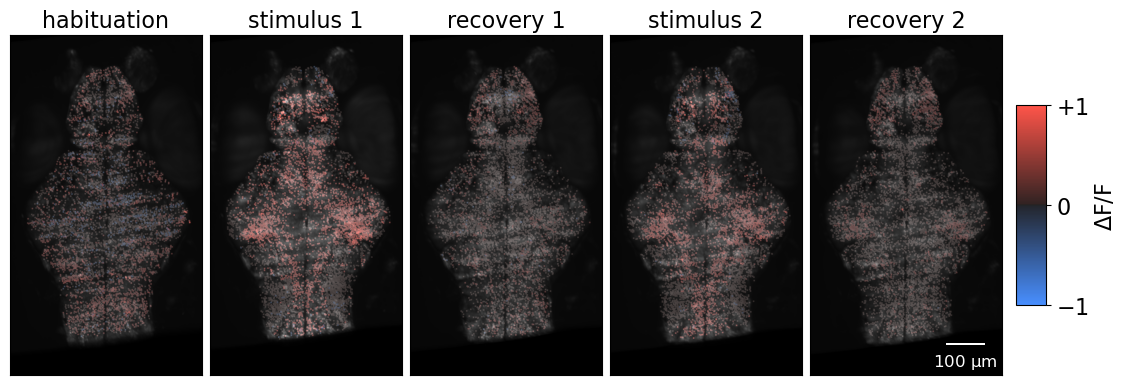

In [21]:
n_images = activity_overlay_selected_max.shape[0]

fig, axs = plt.subplots(1,n_images, constrained_layout=True, figsize=(10, 5))

for n in range(n_images):
    axs[n].imshow(activity_overlay_selected_max[n, 0:1100])
    axs[n].set_title(names_timepoints[n], fontsize=16)

# axs[0].set_ylabel(f'{compound}', fontsize=18, labelpad=15)

# Remove Ticklabels
for ax in axs:
    ax.set_yticks([])
    ax.set_xticks([])

# Add Colorbar
axsColorbar = fig.add_axes([1.01, 0.3, 0.03, 0.4]) # left, bottom, width, height
norm = mpl.colors.Normalize(vmin=-min_max, vmax=min_max)
cbar = mpl.colorbar.ColorbarBase(axsColorbar, cmap = cmap, norm = norm, orientation = 'vertical', ticks = [min_max,0,-min_max])
cbar.ax.tick_params(labelsize=16)
cbar.ax.set_yticklabels([rf'$+{min_max}$', r'$0$', rf'$-{min_max}$'])
cbar.set_label(r'$\Delta$F/F', fontsize=16);

# Add Scalebar
sbar = ScaleBar(dx=0.798, units='um', location='lower right', color='white', box_color='black',
               length_fraction = 0.25, width_fraction=0.005, font_properties={'size':12})  
axs[-1].add_artist(sbar);

### Create and save figures for all fish of the selected compound

In [22]:
for file in os.listdir(f'{root_path}/neurons/analysis'):
    if re.search(f'{compound}_cells_included_regions_zbrain.csv', file):
        fish_number = file.split('_')[0]
        print(f'Working on {fish_number}')
        
        registered = dd.io.load(f'{root_path}/zbrain_registered/over_time/{fish_number}_{compound}_aligned_registered.hdf5')['TZYX']
        
        cells_zbrain_regions = pd.read_csv(f'{root_path}/neurons/analysis/{fish_number}_{compound}_cells_included_regions_zbrain.csv')
        cells_zbrain_regions['z'] = cells_zbrain_regions['z'].round(0)  # no floating points for the planes
        cells_zbrain_regions = cells_zbrain_regions.astype({'z':'int'})
        
        traces = pd.read_csv(f'{root_path}/neurons/analysis/{fish_number}_{compound}_traces_included_regions_zbrain.csv', index_col=0)
        
        # dFF from traces with rolling baseline:
        dff_rows = []
        for i in range(traces.shape[0]):
            trace = traces.values[i, :]
            base = percentile_filter(trace, percentile=percentile, size=window)
            dff  = (trace - base) / (base + 1e-6) # avoid division by zero
            dff_rows.append(dff)
        dFF = pd.DataFrame(dff_rows, index=traces.index, columns=traces.columns)
        
        # mean dF/F per period, per neuron
        n_cells = cells_zbrain_regions.shape[0]
        period_means = []
        for name, start, end in periods:
            cols = [str(f) for f in range(start, end + 1)]
            # mean over frames of this period for each neuron
            period_means.append(dFF[cols].mean(axis=1).to_numpy())
        period_means = np.vstack(period_means)  # shape: (n_periods, n_cells)

        # activity map top/bottom % neurons for average of the time periods
        activity_periods = np.zeros((len(periods),) + registered.shape[1:] + (3,), dtype=np.uint8)
        radius = 3
        print(f'Number of Neurons: {n_cells}')
        n_sel = max(1, int(percent_neurons * n_cells))

        for p_idx in range(len(periods)):
            dff_p = period_means[p_idx]            # mean dF/F for this period (shape: n_cells)
            order = np.argsort(dff_p)              # ascending
            inhibited_idx = order[:n_sel]          # most negative
            activated_idx = order[-n_sel:]         # most positive
            selected = np.unique(np.concatenate([inhibited_idx, activated_idx]))

            for roi_number in selected:
                x = cells_zbrain_regions['x'].iloc[roi_number]
                y = cells_zbrain_regions['y'].iloc[roi_number]
                plane = int(cells_zbrain_regions['z'].iloc[roi_number])
                circle_yx = disk((y, x), radius, shape=activity_periods.shape[2:])
                v = dff_p[roi_number]
                c = colors[np.argmin((vals - v)**2)]  # map mean dF/F to colormap
                activity_periods[p_idx][plane][circle_yx] = c
                
        # average anatomy of selected periods and max projection
        registered_periods_means = np.zeros((len(periods),) + registered.shape[1:], dtype=np.uint8)
        for p_idx, (_, start, end) in enumerate(periods):
            reg_period = registered[start:end+1]          # (T_phase, Z, Y, X)
            # compute mean in float, then cast back to uint8
            registered_periods_means[p_idx] = reg_period.mean(axis=0).astype(np.uint8)
        registered_selected_max = np.max(registered_periods_means, axis=1)
        registered_selected_max_3ch = np.stack((registered_selected_max, registered_selected_max, registered_selected_max), axis=3)
        
        # max projection of average activity of selected periods
        activity_periods_max = np.max(np.abs(activity_periods), axis=1)  # (5, Y, X, 3)
        
        # overlay anatomy + activity
        activity_overlay_selected_max = cv2.addWeighted(registered_selected_max_3ch, 1, activity_periods_max, 1, 0)

        # Figure with max projection and acitivity overlay top/bottom % neurons for average of time periods
        n_images = activity_overlay_selected_max.shape[0]
        fig, axs = plt.subplots(1,n_images, constrained_layout=True, figsize=(10, 5))

        for n in range(n_images):
            axs[n].imshow(activity_overlay_selected_max[n, 0:1100])
            axs[n].set_title(names_timepoints[n], fontsize=16)
            
        # axs[0].set_ylabel(f'{compound}', fontsize=16, labelpad=15)
        # Remove Ticklabels
        for ax in axs:
            ax.set_yticks([])
            ax.set_xticks([])

        # Add Colorbar
        axsColorbar = fig.add_axes([1.01, 0.3, 0.03, 0.4]) # left, bottom, width, height
        norm = mpl.colors.Normalize(vmin=-min_max, vmax=min_max)
        cbar = mpl.colorbar.ColorbarBase(axsColorbar, cmap = cmap, norm = norm, orientation = 'vertical', ticks = [min_max,0,-min_max])
        cbar.ax.tick_params(labelsize=16)
        cbar.ax.set_yticklabels([rf'$+{min_max}$', r'$0$', rf'$-{min_max}$'])
        cbar.set_label(r'$\Delta$F/F', fontsize=16);

        # Add Scalebar
        sbar = ScaleBar(dx=0.798, units='um', location='lower right', color='white', box_color='black',
                        length_fraction = 0.25, width_fraction=0.005, font_properties={'size':12})  
        axs[-1].add_artist(sbar)
        
        path_to_save = f'{root_path}/neurons/analysis/neuronal_activity_overlays/{fish_number}_{compound}_overlay_window{window}_percentile{percentile}.pdf'
        fig.savefig(path_to_save, bbox_inches='tight', pad_inches=0.2)
        plt.close(fig)

Working on fish04
Number of Neurons: 27590
Working on fish08
Number of Neurons: 36093
Working on fish09
Number of Neurons: 31003
Working on fish11
Number of Neurons: 33000
Working on fish12
Number of Neurons: 30011
